In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.style.use("../fopraplot.mplstyle")

In [2]:
odmr = np.genfromtxt("./data/cwODMR/cwODMR.csv", skip_header=1, delimiter=";", usecols=(1,3))
odmr_mag1 = np.genfromtxt("./data/cwODMR_magnet_1/cwODMR.csv", skip_header=1, delimiter=";", usecols=(1,3))
odmr_mag2 = np.genfromtxt("./data/cwODMR_magnet_2/cwODMR.csv", skip_header=1, delimiter=";", usecols=(1,3))
odmr_mag3 = np.genfromtxt("./data/cwODMR_magnet_3/cwODMR.csv", skip_header=1, delimiter=";", usecols=(1,3))
odmr_mag4 = np.genfromtxt("./data/cwODMR_magnet_4/cwODMR.csv", skip_header=1, delimiter=";", usecols=(1,3))

# convert frequencies to GHz and currents to mA
odmr[:,0] *= 1e-9
odmr[:,1] = 1e3*odmr[:,1]
odmr_mag1[:,0] *= 1e-9
odmr_mag1[:,1] = 1e3*odmr_mag1[:,1]
odmr_mag2[:,0] *= 1e-9
odmr_mag2[:,1] = 1e3*odmr_mag2[:,1]
odmr_mag3[:,0] *= 1e-9
odmr_mag3[:,1] = 1e3*odmr_mag3[:,1]
odmr_mag4[:,0] *= 1e-9
odmr_mag4[:,1] = 1e3*odmr_mag4[:,1]


array([1.00016971, 0.0138373 , 0.00511768, 2.86946838])

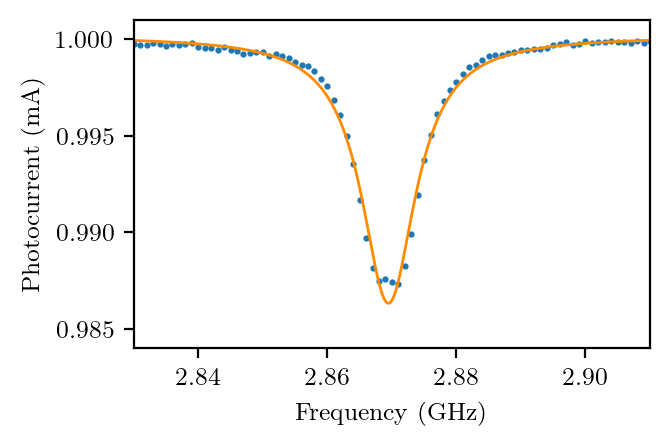

In [3]:
def gauss(x, A, B, s, x0):
    return A * (1 - B * np.exp(-(x-x0)**2 / (2*s**2)))

def lorentzian(x, A, B, w, x0):
    return A * (1 - B / (1 + (x-x0)**2 / w**2))

params, pcov = curve_fit(lorentzian, odmr[:,0], odmr[:,1]+1, p0=(1, 0.013, 0.01, 2.87))

xs = np.linspace(2.83, 2.93, 300)

fig1, ax = plt.subplots()
ax.scatter(odmr[:,0], odmr[:,1]+1, marker=".")
ax.plot(xs, lorentzian(xs, *params), c="darkorange")
ax.set(xlabel="Frequency (GHz)", ylabel="Photocurrent (mA)", xlim=(2.83, 2.91), ylim=(0.984, 1.001))
params

-3.22984

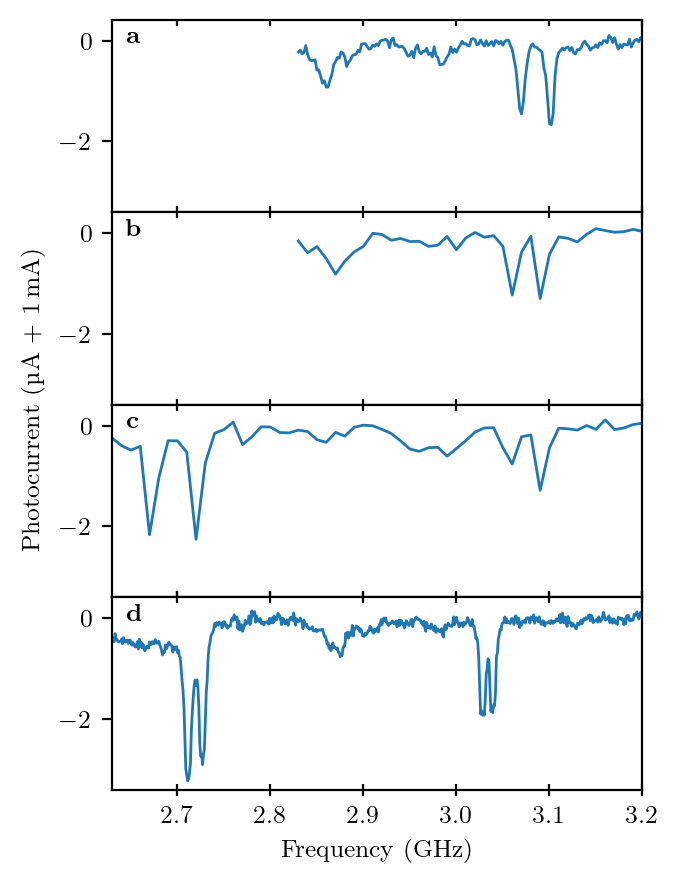

In [4]:
plt.rcParams["figure.autolayout"] = False

fig2, axs = plt.subplots(ncols=1, nrows=4, sharex=True, sharey=True, figsize=(3.42, 5))
fig2.subplots_adjust(hspace=0)

odmr_list = [odmr_mag1, odmr_mag2, odmr_mag3, odmr_mag4]
subplot_labels = ["a", "b", "c", "d"]
for i, data in enumerate(odmr_list):
    axs[i].plot(data[:,0], data[:,1]*1e3)
    axs[i].tick_params(axis="x", which="both", direction="in", top=True, bottom=True, length=2)
    axs[i].text(2.645, -0.05, r"\textbf "+subplot_labels[i])

axs[3].tick_params(axis="x", which="both", direction="inout", top=True, bottom=True, length=4)
axs[3].set(xlabel="Frequency (GHz)", xlim=(2.63, 3.2))
fig2.supylabel(r"Photocurrent (\unit{\micro\A} + \qty{1}{\mA})", fontsize=9, x=-0.01)

# fig2.savefig("./figs/cwodmr_magnets.pdf", bbox_inches="tight")
np.min(odmr_mag4[:,1])*1e3

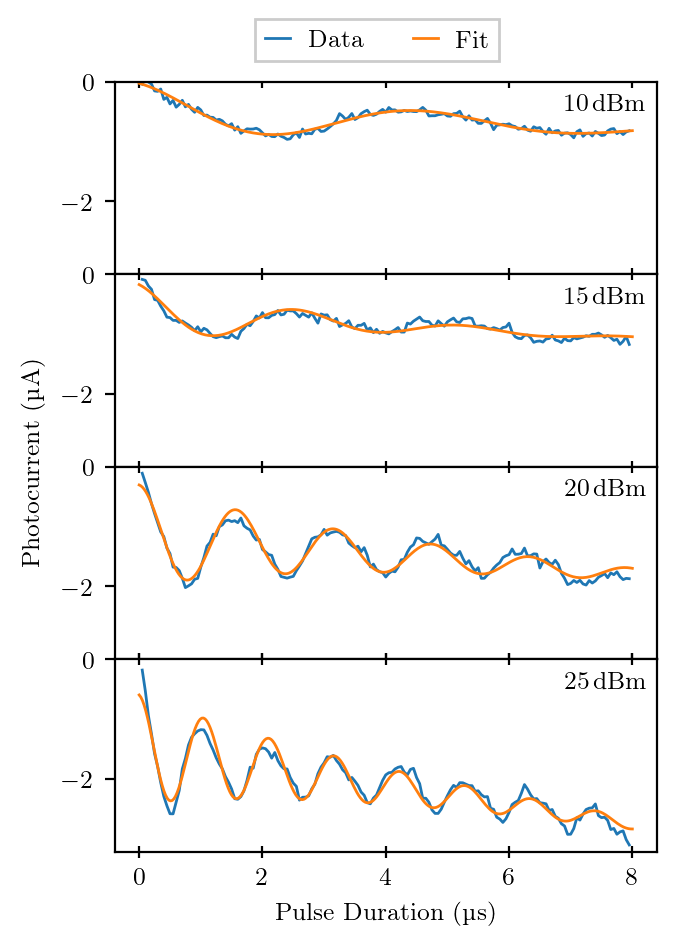

In [5]:
rabi_0dbm = np.genfromtxt("./data/Rabi_0dbm/Rabi.csv", skip_header=1, delimiter=";", usecols=(1,3))
rabi_5dbm = np.genfromtxt("./data/Rabi_-5dbm/Rabi.csv", skip_header=1, delimiter=";", usecols=(1,3))
rabi_10dbm = np.genfromtxt("./data/Rabi_-10dbm/Rabi.csv", skip_header=1, delimiter=";", usecols=(1,3))
rabi_15dbm = np.genfromtxt("./data/Rabi_-15dbm/Rabi.csv", skip_header=1, delimiter=";", usecols=(1,3))

# convert to mu s and muA
rabi_0dbm[:,0] *= 1e-3
rabi_0dbm[:,1] *= 1e6
rabi_5dbm[:,0] *= 1e-3
rabi_5dbm[:,1] *= 1e6
rabi_10dbm[:,0] *= 1e-3
rabi_10dbm[:,1] *= 1e6
rabi_15dbm[:,0] *= 1e-3
rabi_15dbm[:,1] *= 1e6


def damped_cos(t, A, B, gamma, omega, phi, C):
    return A * np.exp(-gamma*t) * np.cos(omega*t + phi) + B - C*t

rabi_list = [rabi_0dbm, rabi_5dbm, rabi_10dbm, rabi_15dbm]
params_list = []
rabi_freqs = []
pcov_list = []
rabi_freqs_err = []

for data in rabi_list:
    params, pcov = curve_fit(damped_cos, data[:,0], data[:,1], p0=(1, -1, 0.3, 3, 0, 0.2))
    params_list += [params]
    pcov_list += [pcov]
    rabi_freqs += [params[3]]
    rabi_freqs_err += [pcov[3,3]**0.5]

rabi_freqs = np.array(rabi_freqs) / (2*np.pi) # in MHz
rabi_freqs_err = np.array(rabi_freqs_err)
mw_powers_dbm = np.array([0, -5, -10, -15]) + 25
ts = np.linspace(0, 8, 300)


##
fig3, axs = plt.subplots(ncols=1, nrows=4, sharex=True, sharey=True, figsize=(3.5, 5))
fig3.subplots_adjust(hspace=0)

for i, data in enumerate(rabi_list):
    axs[3-i].plot(data[:,0], data[:,1], label="Data")
    axs[3-i].plot(ts, damped_cos(ts, *params_list[i]), label="Fit")
    axs[3-i].text(6.9, -0.5, r"$\qty{"+f"{mw_powers_dbm[i]}"+r"}{dBm}$")
    axs[i].tick_params(axis="x", which="both", direction="in", top=True, bottom=True, length=2)

axs[3].set(xlabel=r"Pulse Duration (\unit{\micro\s})", ylim=(-3.22, 0))
axs[3].tick_params(axis="x", which="both", direction="inout", top=True, bottom=True, length=4)

fig3.supylabel(r"Photocurrent (\unit{\micro\A})", fontsize=9, x=-0.01)

h, l = axs[0].get_legend_handles_labels()
fig3.legend(h, l, loc="upper center", ncols=2, bbox_to_anchor=(0.5, 0.95))


# fig3.savefig("./figs/rabi.pdf", bbox_inches="tight")

C:\Users\Linus\AppData\Local\Temp\ipykernel_13964\3648819320.py:11: OptimizeWarning: Covariance of the parameters could not be estimated
  params, pcov = curve_fit(fit, mw_powers, rabi_freqs)


array([0.05626964, 1.        ])

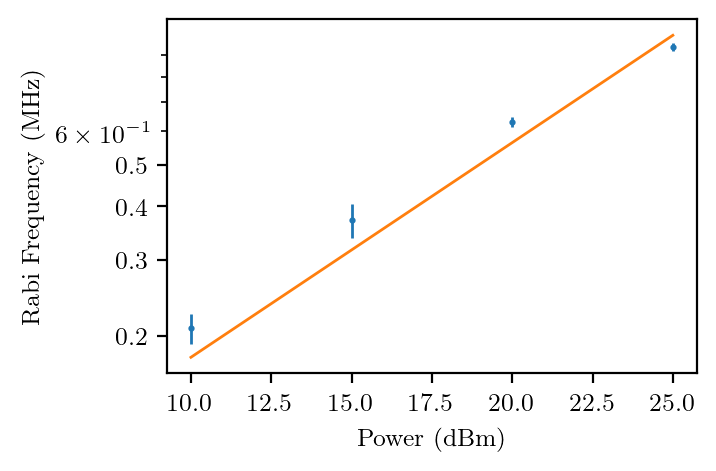

In [6]:
mw_powers = np.array([0, -5, -10, -15]) + 25
# mw_powers = 10**(0.1*mw_powers)

# mw_powers = np.log(mw_powers)
# rabi_freqs = np.log(rabi_freqs)

def fit(x, a, b):
    x = 10**(0.1*mw_powers)
    return a*x**0.5

params, pcov = curve_fit(fit, mw_powers, rabi_freqs)

fig4, ax = plt.subplots()
ax.errorbar(mw_powers, rabi_freqs, yerr=rabi_freqs_err, marker=".", linestyle="")
ax.plot(mw_powers, fit(mw_powers, *params))
ax.set(xlabel="Power (dBm)", ylabel="Rabi Frequency (MHz)", xscale="linear", yscale="log", yticks=[0.2, 0.3, 0.4, 0.5], yticklabels=["0.2", "0.3", "0.4", "0.5"])

params
# rabi_freqs

In [8]:
rabi_freqs

np.pi/np.array(rabi_freqs)

array([0.53162357, 0.79448191, 1.34698598, 2.40556007])